# Image processing fundamentals

Before any deep learning, a lot of computer vision is solved with a few classic operations on pixel arrays: thresholding, morphology, connected components, filtering and edge detection. They are fast, need no training data, and remain the building blocks of most pipelines (including the document scanner in the next notebook).

This notebook applies them to one concrete task, **counting and measuring the coins in a photo**, and then compares filters for removing noise and finding edges. All images come with scikit-image, so nothing needs to be downloaded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, exposure, feature, filters, measure, morphology, segmentation, util
from skimage.color import label2rgb
from skimage.restoration import denoise_bilateral

plt.rcParams["figure.dpi"] = 100

## 1. Images are arrays

A grayscale image is a 2D array of intensities; a colour image adds a third axis for the red, green and blue channels. Most operations below are simple array computations.

shape (303, 384), dtype uint8, range 1-252


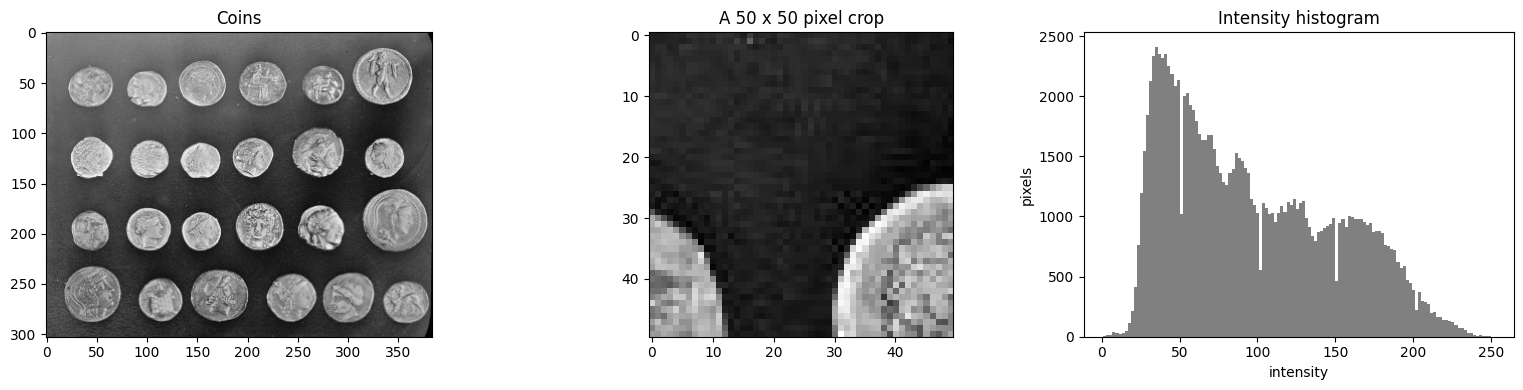

In [2]:
coins = data.coins()
print(f"shape {coins.shape}, dtype {coins.dtype}, range {coins.min()}-{coins.max()}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={"width_ratios": [1.3, 1, 1]})
ax1.imshow(coins, cmap="gray")
ax1.set_title("Coins")
ax2.imshow(coins[150:200, 50:100], cmap="gray", interpolation="nearest")
ax2.set_title("A 50 x 50 pixel crop")
ax3.hist(coins.ravel(), bins=128, color="grey")
ax3.set(title="Intensity histogram", xlabel="intensity", ylabel="pixels")
fig.tight_layout()
plt.show()

The histogram has two broad modes: the darker background and the brighter coins. The illumination is uneven, though: the background gets darker towards the bottom of the image, and some coins are darker than parts of the background.

## 2. Separating coins from the background

### Global thresholding

The simplest segmentation is a single threshold: every pixel brighter than $t$ is "coin". **Otsu's method** chooses $t$ automatically, by maximizing the separation between the two classes of pixels.

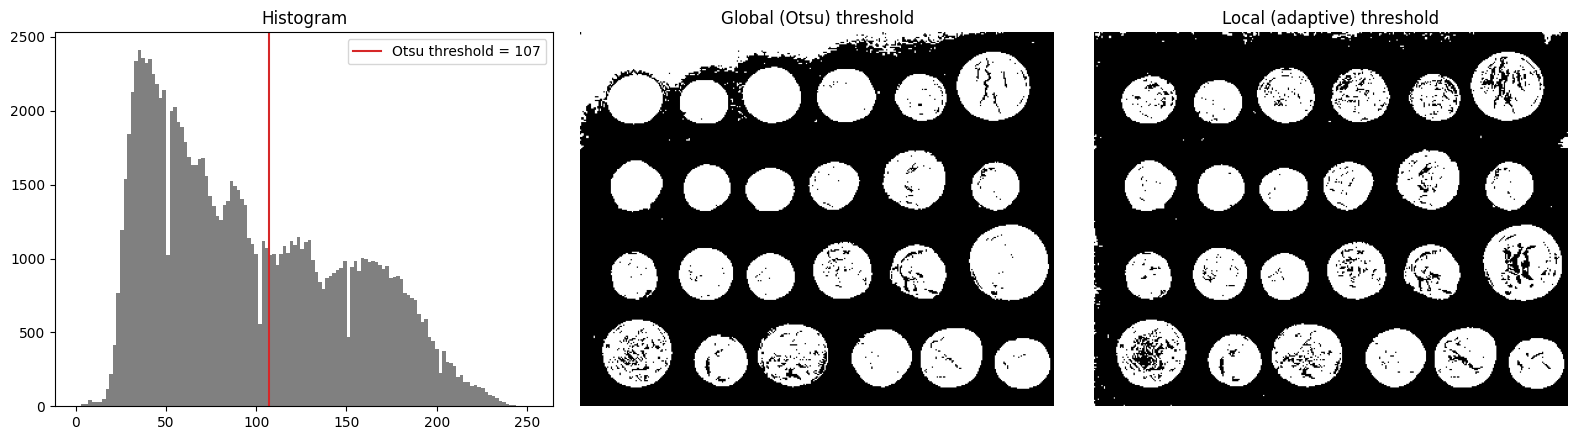

In [3]:
t_otsu = filters.threshold_otsu(coins)
global_mask = coins > t_otsu

# Local thresholding: compare every pixel with the mean of its own neighbourhood
local_mask = coins > filters.threshold_local(coins, block_size=95, offset=-10)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(coins.ravel(), bins=128, color="grey")
axes[0].axvline(t_otsu, color="tab:red", label=f"Otsu threshold = {t_otsu}")
axes[0].legend()
axes[0].set_title("Histogram")
axes[1].imshow(global_mask, cmap="gray")
axes[1].set_title("Global (Otsu) threshold")
axes[2].imshow(local_mask, cmap="gray")
axes[2].set_title("Local (adaptive) threshold")
for ax in axes[1:]:
    ax.axis("off")
fig.tight_layout()
plt.show()

With a single global threshold, the dark coins at the bottom are only partially detected and pieces of bright background appear at the top. A **local threshold** compares each pixel with the average of its neighbourhood, which compensates for the uneven lighting. It gives much better coin outlines, at the price of detecting some texture inside the coins.

An alternative that avoids choosing any threshold is **edge-based segmentation**: find the coin borders, then fill the closed contours.

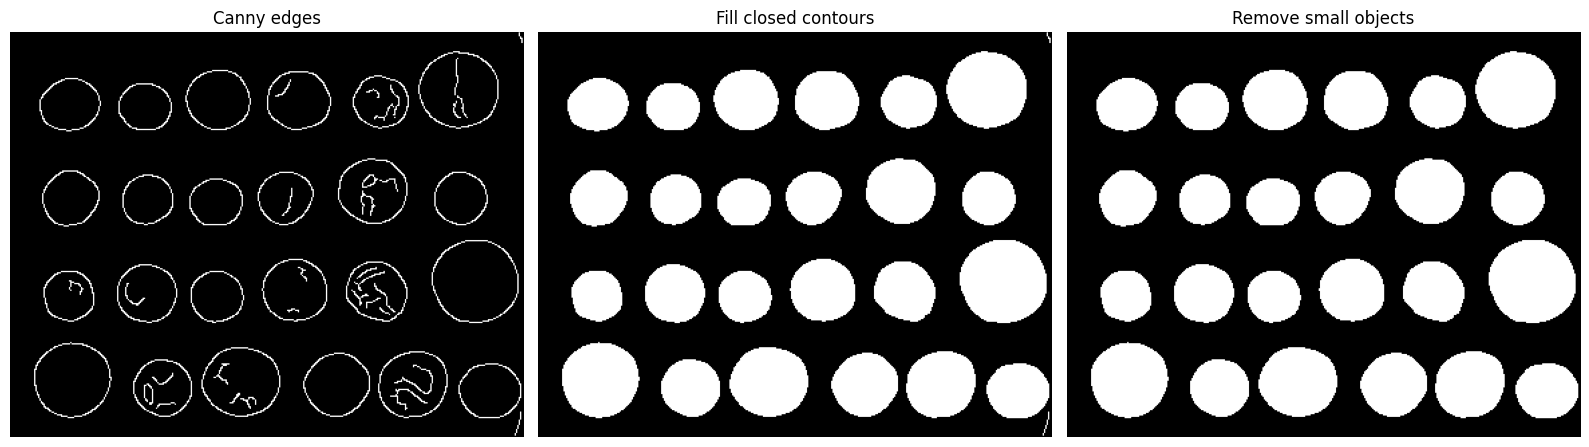

In [4]:
edges = feature.canny(coins, sigma=2.5)
filled = ndi.binary_fill_holes(edges)
cleaned = morphology.remove_small_objects(filled, min_size=150)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, img, title in [(axes[0], edges, "Canny edges"), (axes[1], filled, "Fill closed contours"), (axes[2], cleaned, "Remove small objects")]:
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

Here it works remarkably well, because Canny traces a closed contour around every coin. The approach is fragile, though: a single gap in a contour (a coin touching the image border, a faint edge) and that coin is not filled at all. Region-based methods degrade more gracefully, so we continue with the local threshold.

### Morphology: cleaning a binary mask

**Mathematical morphology** modifies a binary mask with a small shape, the *structuring element* (here a disk):

- **dilation** grows objects and fills small gaps;
- **erosion** shrinks them and removes thin protrusions;
- **opening** (erosion then dilation) removes small specks;
- **closing** (dilation then erosion) fills small holes and joins nearby fragments.

We clean the local-threshold mask: closing joins the fragments of each coin, filling removes interior holes, and opening and size filtering remove the remaining background specks.

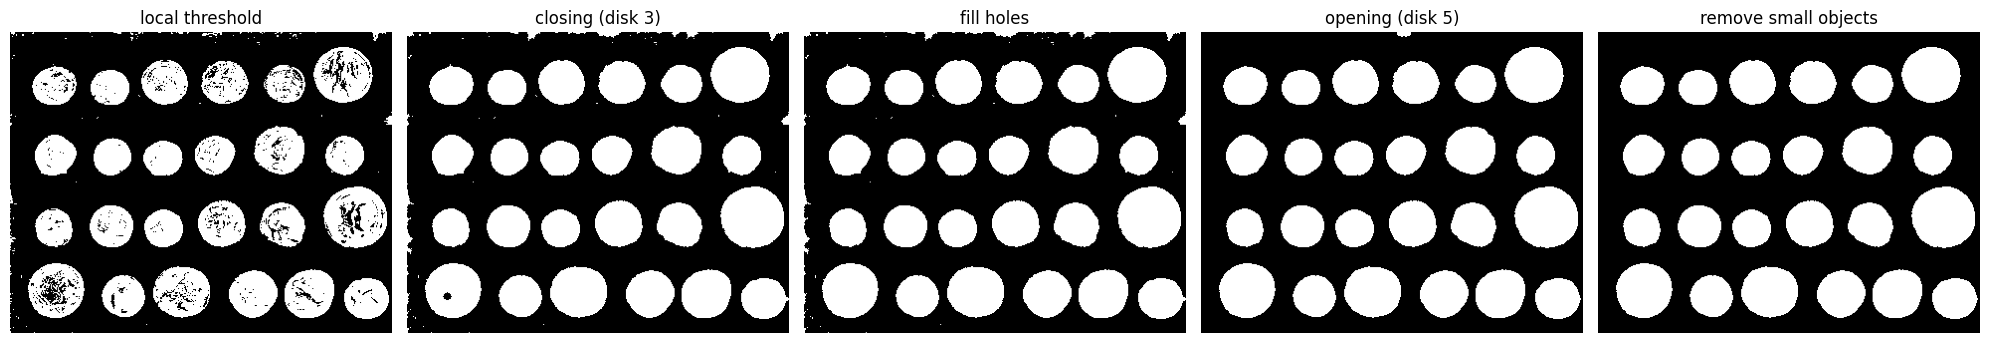

In [5]:
steps = {"local threshold": local_mask}
steps["closing (disk 3)"] = morphology.binary_closing(steps["local threshold"], morphology.disk(3))
steps["fill holes"] = ndi.binary_fill_holes(steps["closing (disk 3)"])
steps["opening (disk 5)"] = morphology.binary_opening(steps["fill holes"], morphology.disk(5))
steps["remove small objects"] = morphology.remove_small_objects(steps["opening (disk 5)"], min_size=300)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (title, img) in zip(axes, steps.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()
mask = steps["remove small objects"]

## 3. Counting and measuring: connected components

A **connected component** is a group of foreground pixels that touch each other. Labelling the components turns a binary mask into a list of objects, and `regionprops` measures each one: area, centroid, equivalent diameter, eccentricity, and so on.

objects found: 24


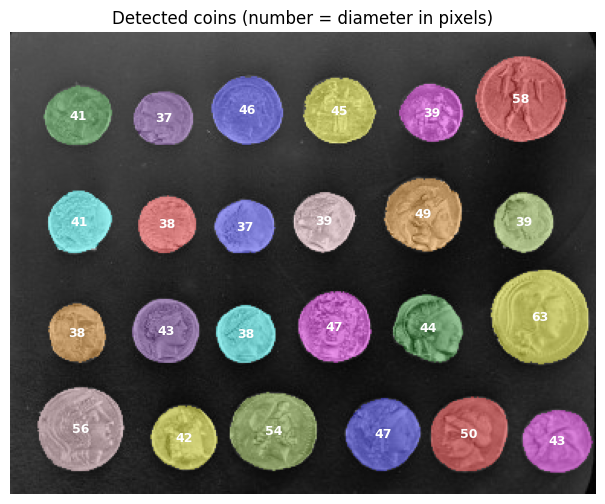

,label,area,equivalent_diameter_area,eccentricity,intensity_mean
11,12,1088.0,37.22,0.44,193.98
5,6,1097.0,37.37,0.42,184.36
10,11,1108.0,37.56,0.33,191.27
16,17,1130.0,37.93,0.29,153.96
17,18,1161.0,38.45,0.26,176.73
9,10,1179.0,38.74,0.27,169.66
3,4,1210.0,39.25,0.39,154.71
8,9,1212.0,39.28,0.38,171.68
7,8,1302.0,40.72,0.36,190.02
4,5,1345.0,41.38,0.51,168.02


In [6]:
labels = measure.label(mask)
props = pd.DataFrame(measure.regionprops_table(labels, intensity_image=coins,
                                               properties=["label", "area", "equivalent_diameter_area", "eccentricity", "intensity_mean", "centroid"]))
print(f"objects found: {labels.max()}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(label2rgb(labels, image=coins, bg_label=0, alpha=0.35))
for _, r in props.iterrows():
    ax.text(r["centroid-1"], r["centroid-0"], f"{r['equivalent_diameter_area']:.0f}", color="white", ha="center", va="center", fontsize=9, weight="bold")
ax.set_title("Detected coins (number = diameter in pixels)")
ax.axis("off")
plt.show()
props.drop(columns=["centroid-0", "centroid-1"]).round(2).sort_values("area")

The pipeline finds **24 objects**, exactly the 24 coins in the image, with no false detections. Their equivalent diameters range from about 37 to 63 pixels, and their eccentricities stay below 0.55, consistent with near-circular shapes. With a known scale (a ruler in the picture), the diameters would identify the denominations.

### Separating touching objects: the watershed

When objects touch, a mask merges them into one component. The **watershed** transform separates them: compute, for every foreground pixel, its distance to the background; the distance has a peak at the centre of each object, and "flooding" from these peaks draws borders where the floods meet.

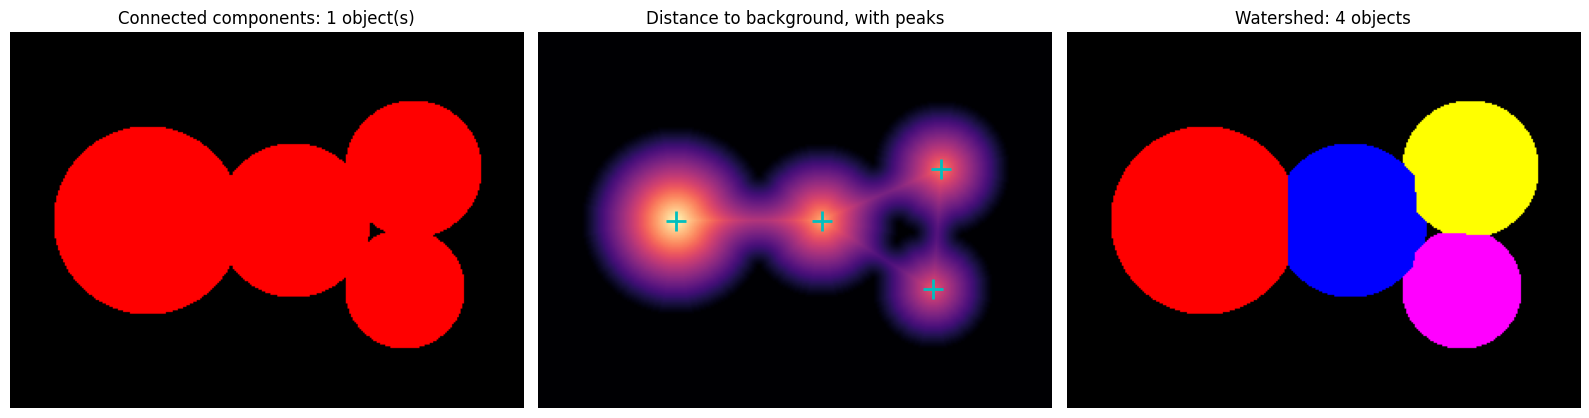

In [7]:
blobs = np.zeros((220, 300), bool)
yy, xx = np.mgrid[:220, :300]
for cy, cx, r in [(110, 80, 55), (110, 165, 45), (80, 235, 40), (150, 230, 35)]:
    blobs |= (yy - cy) ** 2 + (xx - cx) ** 2 < r ** 2

distance = ndi.distance_transform_edt(blobs)
peaks = feature.peak_local_max(distance, min_distance=20, labels=measure.label(blobs))
markers = np.zeros_like(distance, dtype=int)
markers[tuple(peaks.T)] = np.arange(1, len(peaks) + 1)
separated = segmentation.watershed(-distance, markers, mask=blobs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].imshow(label2rgb(measure.label(blobs), bg_label=0))
axes[0].set_title(f"Connected components: {measure.label(blobs).max()} object(s)")
axes[1].imshow(distance, cmap="magma")
axes[1].plot(peaks[:, 1], peaks[:, 0], "c+", ms=14, mew=2)
axes[1].set_title("Distance to background, with peaks")
axes[2].imshow(label2rgb(separated, bg_label=0))
axes[2].set_title(f"Watershed: {separated.max()} objects")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

Four overlapping disks form a single connected component; the watershed of the distance transform recovers all four.

## 4. Filtering noise

Real images are noisy. We corrupt the classic *cameraman* image with two kinds of noise and compare filters, measuring the quality with the **peak signal-to-noise ratio** (PSNR, in dB; higher is better).

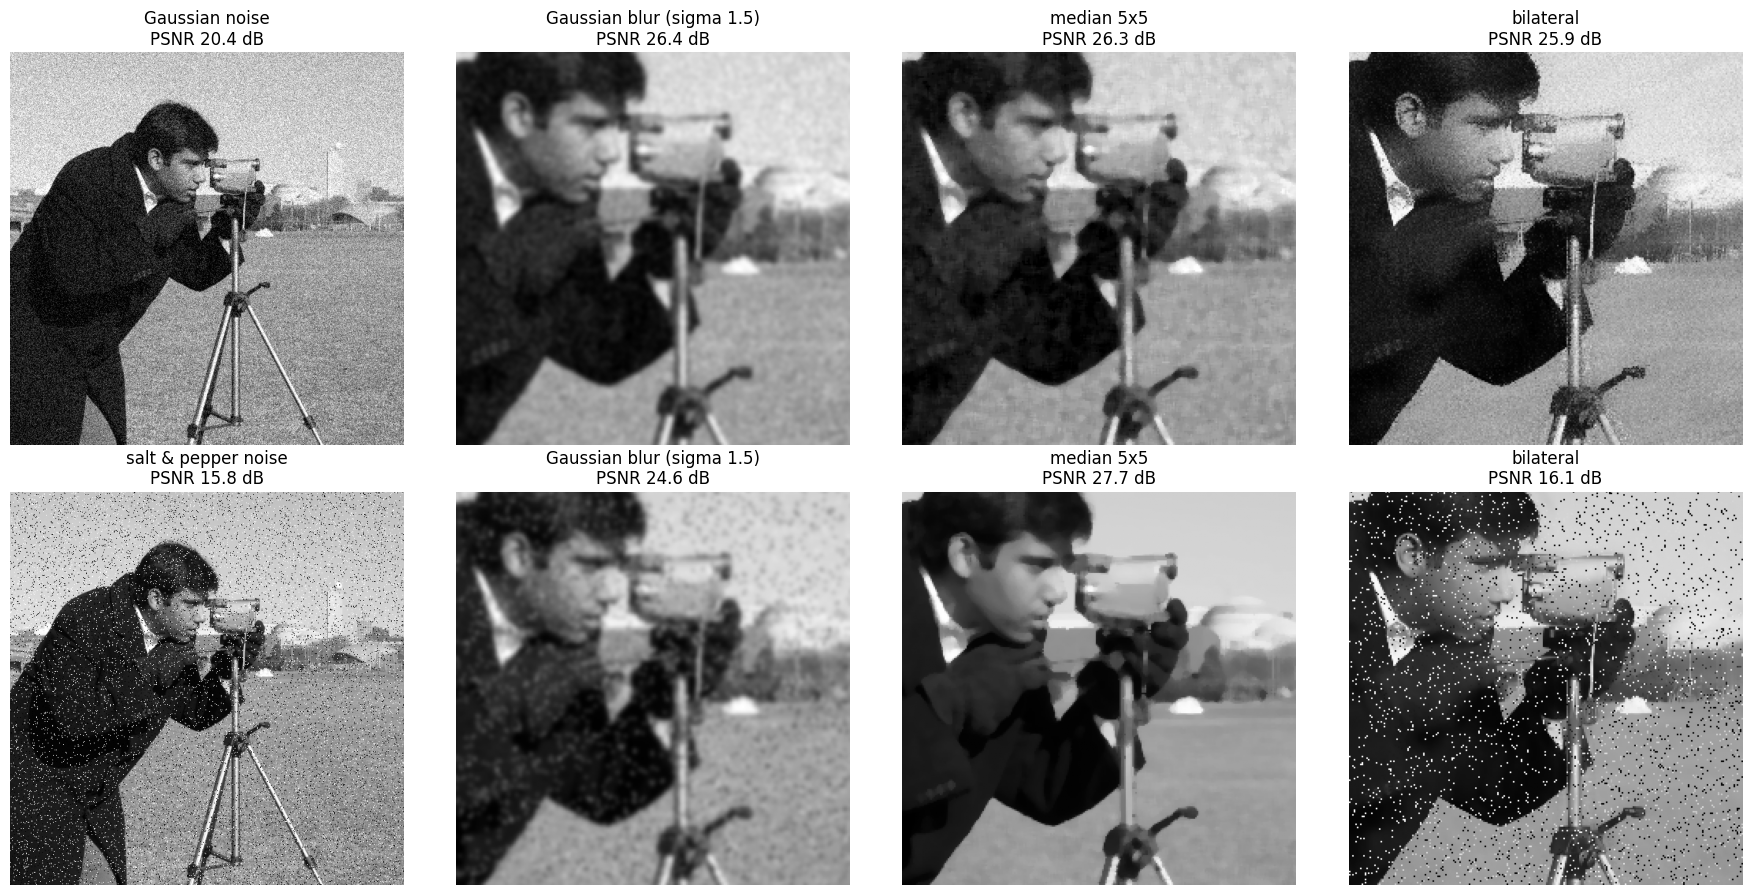

,Gaussian noise,salt & pepper noise
Gaussian blur (sigma 1.5),26.4,24.6
median 5x5,26.3,27.7
bilateral,25.9,16.1


In [8]:
from skimage.metrics import peak_signal_noise_ratio as psnr

clean = util.img_as_float(data.camera())
noisy = {
    "Gaussian noise": util.random_noise(clean, mode="gaussian", var=0.01, rng=0),
    "salt & pepper noise": util.random_noise(clean, mode="s&p", amount=0.08, rng=0),
}
filters_ = {
    "Gaussian blur (sigma 1.5)": lambda im: filters.gaussian(im, sigma=1.5),
    "median 5x5": lambda im: filters.median(im, np.ones((5, 5))),
    "bilateral": lambda im: denoise_bilateral(im, sigma_color=0.15, sigma_spatial=3),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
scores = {}
for row, (noise_name, im) in enumerate(noisy.items()):
    axes[row, 0].imshow(im, cmap="gray")
    axes[row, 0].set_title(f"{noise_name}\nPSNR {psnr(clean, im, data_range=1):.1f} dB")
    for col, (f_name, f) in enumerate(filters_.items(), start=1):
        out = f(im)
        scores.setdefault(f_name, {})[noise_name] = psnr(clean, out, data_range=1)
        axes[row, col].imshow(out[100:350, 150:400], cmap="gray")
        axes[row, col].set_title(f"{f_name}\nPSNR {scores[f_name][noise_name]:.1f} dB")
for ax in axes.flat:
    ax.axis("off")
fig.tight_layout()
plt.show()
pd.DataFrame(scores).T.round(1)

The best filter depends on the noise:

- For **Gaussian noise**, all three filters improve the PSNR by several dB and perform similarly; the bilateral filter keeps edges visibly sharper (look at the camera and the coat) even if its PSNR is not the highest.
- For **salt & pepper noise**, the **median** filter is clearly best. Isolated black and white pixels are outliers, and the median ignores outliers, while a Gaussian blur smears them into grey blotches. The bilateral filter treats the impulses as edges to preserve and makes things worse (16 dB).

## 5. Edges

Edges are where the intensity changes sharply. The **Sobel** filter estimates the gradient with small convolution kernels; its magnitude is high on edges but also on noise and texture. **Canny** builds on it: it smooths the image first, keeps only the local maxima of the gradient along its direction (thin edges), and links edge pixels with two thresholds (hysteresis), which removes isolated responses.

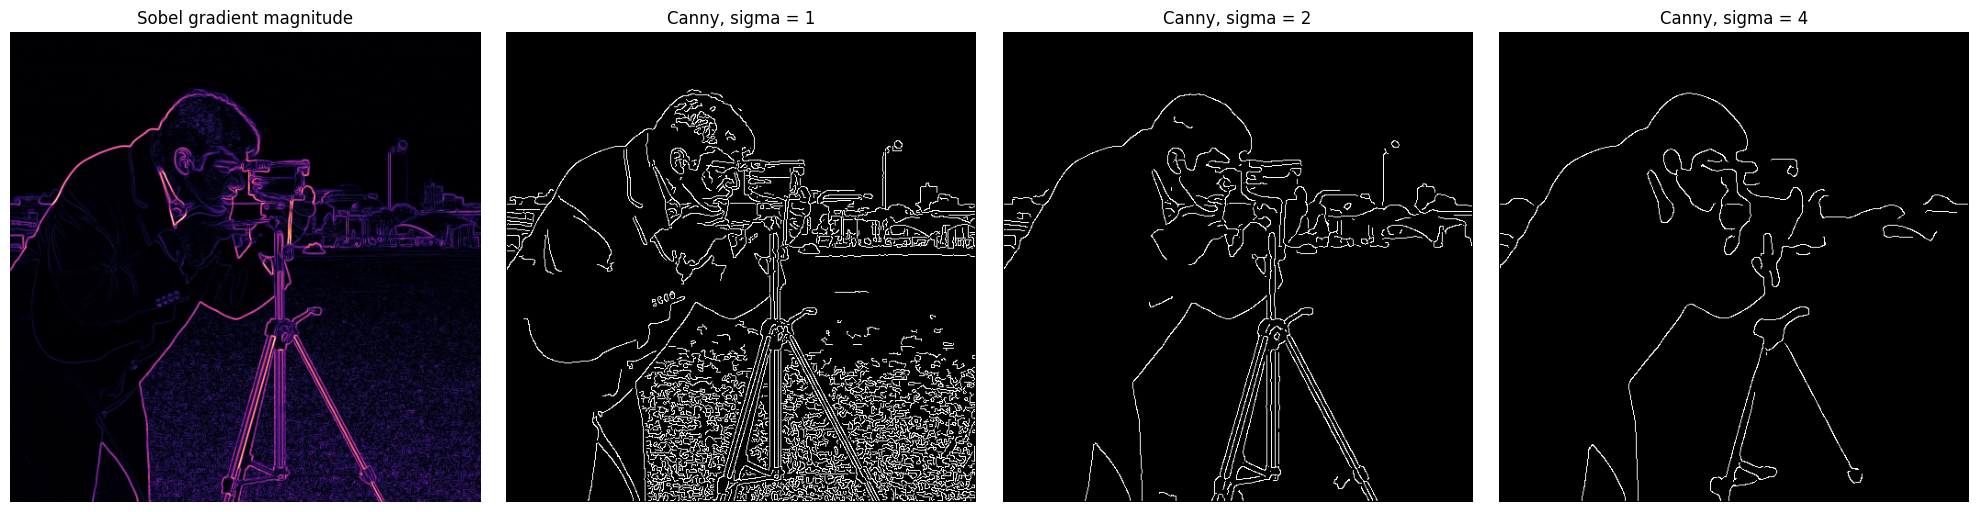

In [9]:
im = clean
sobel = filters.sobel(im)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(sobel, cmap="magma")
axes[0].set_title("Sobel gradient magnitude")
for ax, sigma in zip(axes[1:], [1, 2, 4]):
    ax.imshow(feature.canny(im, sigma=sigma), cmap="gray")
    ax.set_title(f"Canny, sigma = {sigma}")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

The smoothing parameter of Canny sets the **scale** of the edges: with $\sigma = 1$ every blade of grass and the texture of the coat produce edges; with $\sigma = 4$ only the main contours of the man, the camera and the tripod remain. Choosing the scale is choosing which structures matter, which is exactly what the document scanner will do to find the borders of a sheet of paper while ignoring the handwriting on it.

## Summary

- **Global thresholds** (Otsu) are simple but fail with uneven lighting; **local thresholds** adapt to it.
- **Morphological** operations clean binary masks: closing joins fragments, opening removes specks, hole filling completes objects.
- **Connected components** and `regionprops` turn a mask into measured objects; the **watershed** of the distance transform separates touching ones.
- **Median** filtering is the right tool for impulsive noise; Gaussian and bilateral filters for Gaussian noise, the bilateral one preserving edges.
- **Canny** gives thin, clean edges, and its $\sigma$ selects the scale of the structures to detect.